# Train CNN variants: orig / clean / insnorm x 5 seeds

Fork of `training/notebooks/cnn/training_baseline-bn-c64-c128-c256-c256-d256.ipynb`
(architecture, hyperparameters, split, callbacks — all identical to the published
Table 4/Table 3 spec). Two factors change, isolated by variant:

| Variant | Silent `C_diminished_4` clips | Input normalization |
|---|---|---|
| `orig` | kept (7,200) | `BatchNormalization(axis=1)` — as published |
| `clean` | dropped (7,184) | `BatchNormalization(axis=1)` |
| `insnorm` | dropped (7,184) | per-sample standardization (no learned params, matches the baseline-centroid `corr` preprocessing) |

5 seeds per variant (42, 43, 44, 45, 46) = 15 runs. Metrics are written for every
run; full weights are saved **only for seed 42** of each variant (disk budget).

**Batch size: 32, matching Table 4 exactly** — training now runs on an RTX 2080 Ti
(11GB) via eGPU, so no deviation is needed. Earlier attempts on the laptop's 4GB
3050 Ti are worth recording since they nearly became a silent correctness bug:
batch=32 OOM'd outright; batch=16 passed isolated smoke tests but hit a genuine
`ResourceExhaustedError` mid-run (Adam's moment buffers for the 36608x256 Dense
layer); batch=8 avoided OOM entirely but was **numerically broken** — stuck at
chance accuracy from epoch 1, confirmed by an isolated controlled test that
changed only the batch size. None of that applies here. GPU selection is pinned
explicitly by device name (`"2080"`) rather than trusting device index 0, since
TensorFlow's GPU ordering does not match `nvidia-smi`'s on this machine. Real
training runs as one OS subprocess per (variant, seed) via `run_variant.py` — see
the "Training loop" section below for why (a separate, already-fixed GPU-memory-
leak issue from running all runs in one process).

Does not modify `training/notebooks/cnn/`, `training/features/training.npz`, or the
shipped model. `orig`/seed 42 now matches the published recipe in every
hyperparameter (same features, same `train_test_split(random_state=42)`, same
architecture/callbacks, same batch=32) — it is both the sanity check that this
fork reproduces near-1.0 in-domain performance, and the closest same-conditions
comparison to the shipped model available without its exact original run seed
trace.

## Config

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from pathlib import Path
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support
from tensorflow.keras.utils import to_categorical

ROOT = Path("../..").resolve()  # training/
FEATURES_PATH = ROOT / "features" / "training.npz"
OUT_DIR = Path("variant-results")
WEIGHTS_DIR = Path("weights")
OUT_DIR.mkdir(exist_ok=True)
WEIGHTS_DIR.mkdir(exist_ok=True)
PROGRESS_CSV = OUT_DIR / "progress.csv"

SEEDS = [42, 43, 44, 45, 46]
VARIANTS = ["orig", "clean", "insnorm"]
SAVE_WEIGHTS_SEED = 42  # only this seed's weights are persisted, per variant

CNN_VALIDATION_SPLIT = 0.1
CNN_TEST_SIZE = 0.1
CNN_EPOCHS = 50
# RTX 2080 Ti (11GB) now available via eGPU -- back to the published batch_size=32,
# no deviation needed. (History, resolved: the 4GB laptop 3050 Ti OOM'd at
# batch=32; batch=16 hit a real OOM on Adam's moment buffers mid-run; batch=8
# avoided OOM but was numerically broken -- stuck at chance accuracy from epoch 1,
# confirmed via an isolated controlled test comparing batch=16 vs batch=8 on
# identical code/seed/data. Actual training runs via run_variant.py subprocesses
# -- see next section -- this constant is kept here for documentation/consistency.)
CNN_BATCH_SIZE = 32
CNN_LEARNING_RATE = 0.001
GPU_NAME_PREFERENCE = "2080"  # pin to the eGPU explicitly; TF's device order != nvidia-smi's

physical_devices = tf.config.list_physical_devices('GPU')
chosen_gpu = physical_devices[0] if physical_devices else None
for _gpu in physical_devices:
    _name = tf.config.experimental.get_device_details(_gpu).get("device_name", "")
    if GPU_NAME_PREFERENCE in _name:
        chosen_gpu = _gpu
        break
if chosen_gpu is not None:
    tf.config.set_visible_devices(chosen_gpu, "GPU")
    tf.config.experimental.set_memory_growth(chosen_gpu, True)
    print(f"Using GPU: {tf.config.experimental.get_device_details(chosen_gpu).get('device_name')}")

print(f"TF {tf.__version__}, GPUs seen: {physical_devices}")
print(f"features: {FEATURES_PATH} (exists={FEATURES_PATH.exists()})")
print(f"runs: {len(VARIANTS)} variants x {len(SEEDS)} seeds = {len(VARIANTS)*len(SEEDS)}")

Using GPU: NVIDIA GeForce RTX 2080 Ti
TF 2.15.0, GPUs seen: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
features: /home/seya/code/chord-detection/training/features/training.npz (exists=True)
runs: 3 variants x 5 seeds = 15


## Load features once; define the two silent/clean index sets

In [2]:
_d = np.load(FEATURES_PATH)
FEATURES_ALL = _d["features"]  # (7200, 216, 188)
LABELS_ALL = _d["labels"]

_flat = FEATURES_ALL.reshape(len(FEATURES_ALL), -1)
SILENT_IDX = np.where(np.abs(_flat).max(axis=1) == 0)[0]
CLEAN_IDX = np.setdiff1d(np.arange(len(FEATURES_ALL)), SILENT_IDX)

pd.DataFrame({"npz_index": SILENT_IDX, "class": LABELS_ALL[SILENT_IDX]}).to_csv(
    OUT_DIR / "excluded_indices.csv", index=False
)

assert len(SILENT_IDX) == 16 and set(LABELS_ALL[SILENT_IDX]) == {"C_diminished_4"}
print(f"total={len(FEATURES_ALL)}  silent={len(SILENT_IDX)}  clean={len(CLEAN_IDX)}")

INDEX_SETS = {"orig": np.arange(len(FEATURES_ALL)), "clean": CLEAN_IDX, "insnorm": CLEAN_IDX}

total=7200  silent=16  clean=7184


## Model factory

Identical to `build_model` in the original notebook (4x Conv2D/MaxPool 64→256,
Dense 256, Dropout 0.5, Softmax 36) except the first layer:
- `orig` / `clean`: `BatchNormalization(axis=1)` — matches the shipped model
  (verified against `training/models/model-bn-c64-c128-c256-c256-d256.keras`,
  which uses `axis=[1]`, i.e. per-frequency-bin running statistics, fixed at
  inference and identical across samples).
- `insnorm`: a parameter-free `Lambda` layer doing per-sample mean/std
  standardization over the full (freq, time, channel) volume — the network-side
  analogue of the baseline-centroid `corr` preprocessing.

In [3]:
def per_sample_standardize(x):
    m = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
    s = tf.math.reduce_std(x, axis=[1, 2, 3], keepdims=True)
    return (x - m) / (s + 1e-6)

def build_model(input_shape, num_classes, variant):
    norm_layer = (
        layers.Lambda(per_sample_standardize, name="per_sample_standardize")
        if variant == "insnorm"
        else layers.BatchNormalization(axis=1)
    )
    model = models.Sequential([
        Input(shape=input_shape),
        norm_layer,
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=CNN_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def get_callbacks():
    return [
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, verbose=0),
        callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=0),
    ]

# sanity: parameter count should match the shipped model for orig/clean (same BN layer)
_m = build_model((216, 188, 1), 36, "orig")
print("orig/clean params:", _m.count_params())
_m2 = build_model((216, 188, 1), 36, "insnorm")
print("insnorm params:   ", _m2.count_params(), "(fewer: Lambda has 0 trainable params vs BatchNorm's 4*216)")

orig/clean params: 10341764
insnorm params:    10340900 (fewer: Lambda has 0 trainable params vs BatchNorm's 4*216)


## Training loop — one subprocess per run (checkpointed — safe to resume)

**Structural fix:** running all 15 (variant, seed) combinations in-process, even
with `tf.keras.backend.clear_session()` between them, leaked/fragmented GPU
memory on this machine — run 1 (`orig`/42) succeeded, then every subsequent run
failed with `InternalError: ... Dst tensor is not initialized` (GPU stayed
pinned at ~2.2GB used with 0% utilization). Verified fix: each run as its own
OS process (`training/notebooks/cnn-v2/run_variant.py`, invoked via
`subprocess`) gets a fresh CUDA context guaranteed by process exit — confirmed
with two consecutive smoke runs, GPU memory returning to ~4MB after each.

Same split recipe as the original: stratified 80/10/10 via `train_test_split`,
`validation_split=0.1` taken from the training slice by `model.fit`.
`random_state` is set to the run's seed. `run_variant.py` mirrors this
notebook's architecture/hyperparameters exactly (including the batch=16
deviation noted in the title cell) and writes to the same
`variant-results/progress.csv` / `failures.csv`.

In [4]:
def load_progress():
    if PROGRESS_CSV.exists():
        return pd.read_csv(PROGRESS_CSV)
    return pd.DataFrame(columns=["variant", "seed"])

def load_failures():
    fpath = OUT_DIR / "failures.csv"
    if fpath.exists():
        return pd.read_csv(fpath)
    return pd.DataFrame(columns=["variant", "seed", "error"])

print("helpers defined. Real training now runs via run_variant.py subprocesses (next cell).")

helpers defined. Real training now runs via run_variant.py subprocesses (next cell).


In [5]:
import subprocess

progress = load_progress()
done = set(zip(progress["variant"], progress["seed"])) if len(progress) else set()
failures = []

for variant in VARIANTS:
    for seed in SEEDS:
        if (variant, seed) in done:
            print(f"skip {variant}/seed{seed} (already done)")
            continue
        print(f"=== {variant} / seed {seed} ===", flush=True)
        result = subprocess.run(
            ["uv", "run", "python", "run_variant.py", "--variant", variant, "--seed", str(seed)],
            cwd=str(Path.cwd()), capture_output=True, text=True,
        )
        print(result.stdout[-500:])
        if result.returncode != 0:
            print(f"FAILED {variant}/seed{seed} (exit {result.returncode}):")
            print(result.stderr[-1000:])
            failures.append({"variant": variant, "seed": seed})

progress = load_progress()  # re-read: run_variant.py wrote directly to PROGRESS_CSV
failures_df = load_failures()
print(f"\nALL RUNS ATTEMPTED. {len(progress)} succeeded, {len(failures_df)} failed.")
progress

=== orig / seed 42 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK orig/seed42: {'variant': 'orig', 'seed': 42, 'n_train': 6480, 'n_test': 720, 'epochs_run': 16, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== orig / seed 43 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK orig/seed43: {'variant': 'orig', 'seed': 43, 'n_train': 6480, 'n_test': 720, 'epochs_run': 24, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== orig / seed 44 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK orig/seed44: {'variant': 'orig', 'seed': 44, 'n_train': 6480, 'n_test': 720, 'epochs_run': 15, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== orig / seed 45 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK orig/seed45: {'variant': 'orig', 'seed': 45, 'n_train': 6480, 'n_test': 720, 'epochs_run': 14, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== orig / seed 46 ===


...

Using GPU: NVIDIA GeForce RTX 2080 Ti
OK insnorm/seed43: {'variant': 'insnorm', 'seed': 43, 'n_train': 6465, 'n_test': 719, 'epochs_run': 7, 'test_accuracy': 0.027816411682892908, 'test_macro_precision': 0.0007726781023025807, 'test_macro_recall': 0.027777777777777776, 'test_macro_f1': 0.0015035333032626672, 'recall_D_minor_4': 0.0, 'recall_E_diminished_4': 0.0, 'recall_G#_diminished_4': 0.0}

=== insnorm / seed 44 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK insnorm/seed44: {'variant': 'insnorm', 'seed': 44, 'n_train': 6465, 'n_test': 719, 'epochs_run': 17, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== insnorm / seed 45 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK insnorm/seed45: {'variant': 'insnorm', 'seed': 45, 'n_train': 6465, 'n_test': 719, 'epochs_run': 16, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}

=== insnorm / seed 46 ===


Using GPU: NVIDIA GeForce RTX 2080 Ti
OK insnorm/seed46: {'variant': 'insnorm', 'seed': 46, 'n_train': 6465, 'n_test': 719, 'epochs_run': 10, 'test_accuracy': 1.0, 'test_macro_precision': 1.0, 'test_macro_recall': 1.0, 'test_macro_f1': 1.0, 'recall_D_minor_4': 1.0, 'recall_E_diminished_4': 1.0, 'recall_G#_diminished_4': 1.0}


ALL RUNS ATTEMPTED. 15 succeeded, 0 failed.


,variant,seed,n_train,n_test,epochs_run,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,recall_D_minor_4,recall_E_diminished_4,recall_G#_diminished_4
0,orig,42,6480,720,16,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
1,orig,43,6480,720,24,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
2,orig,44,6480,720,15,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
3,orig,45,6480,720,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
4,orig,46,6480,720,13,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
5,clean,42,6465,719,10,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
6,clean,43,6465,719,14,0.998609,0.998677,0.998538,0.998572,1.0,1.0,1.0
7,clean,44,6465,719,14,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
8,clean,45,6465,719,23,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0
9,clean,46,6465,719,21,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0


## Sanity check: `orig`/seed 42 vs. the published run

In [6]:
row = progress[(progress.variant == "orig") & (progress.seed == 42)]
if len(row):
    r = row.iloc[0]
    print(f"orig/seed42 test accuracy: {r.test_accuracy:.4f} (published resubstitution: 0.9999)")
    assert r.test_accuracy > 0.99, "orig/seed42 should reproduce near-1.0 in-domain performance"
    print("Sanity check OK: fork trains consistently with the published recipe.")
else:
    print("orig/seed42 not yet run.")

orig/seed42 test accuracy: 1.0000 (published resubstitution: 0.9999)
Sanity check OK: fork trains consistently with the published recipe.


## Plots: training curves and final metrics

Per-epoch loss/accuracy for every run (`variant-results/history/*.csv`, written
by `run_variant.py`), plus a seed-level view of the final test metrics so the
`insnorm` vs `orig`/`clean` comparison doesn't require reading a wide table.

15 run(s) with saved epoch history


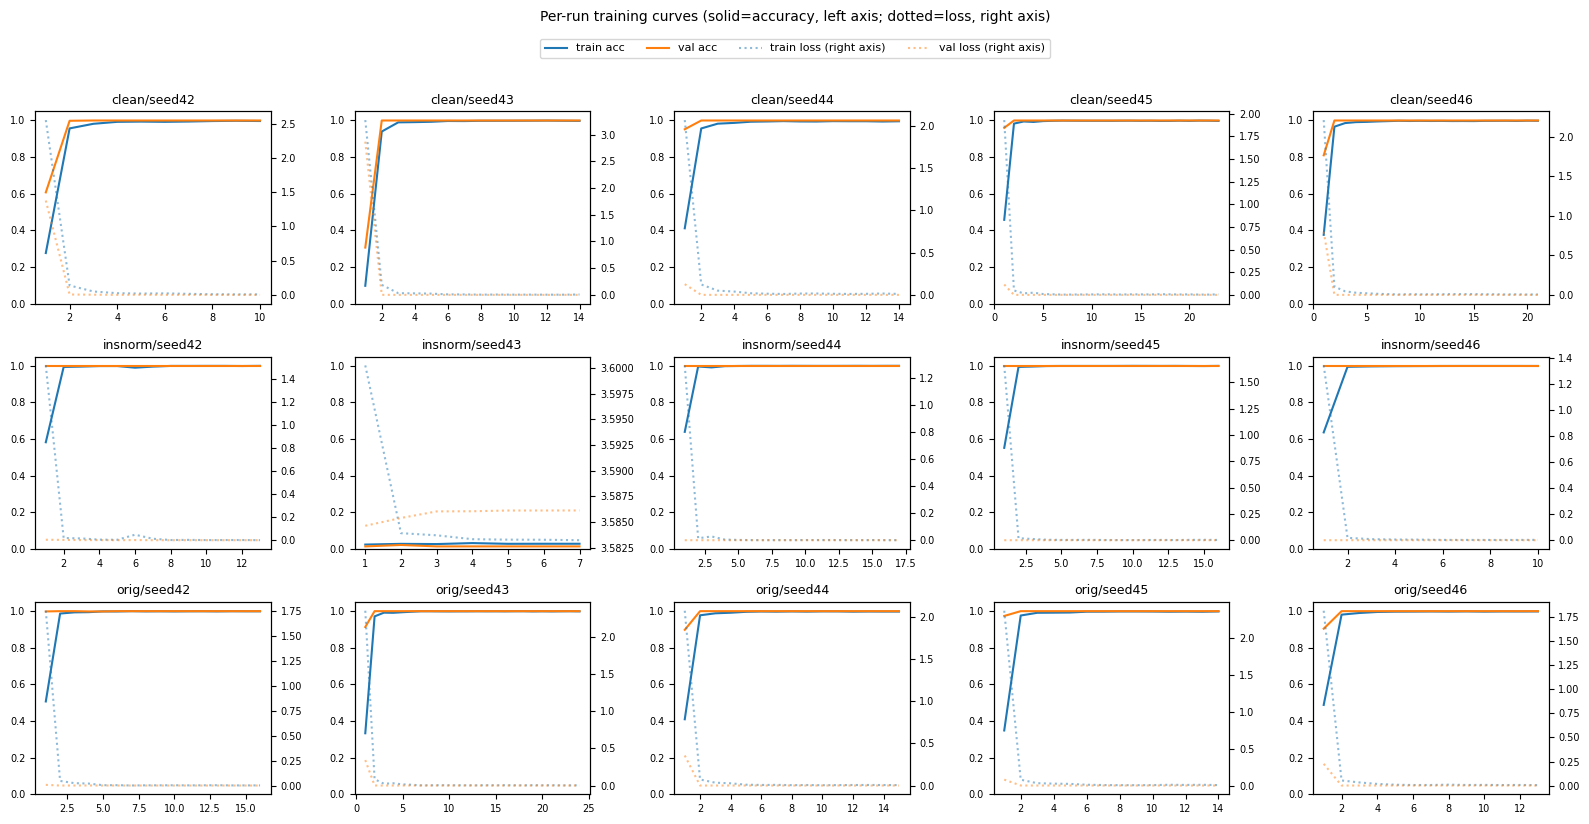

In [7]:
import matplotlib.pyplot as plt

HISTORY_DIR = OUT_DIR / "history"
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

hist_files = sorted(HISTORY_DIR.glob("*.csv")) if HISTORY_DIR.exists() else []
print(f"{len(hist_files)} run(s) with saved epoch history")

if hist_files:
    n = len(hist_files)
    ncols = 5
    nrows = -(-n // ncols)  # ceil
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), squeeze=False)
    for i, f in enumerate(hist_files):
        h = pd.read_csv(f)
        ax = axes[i // ncols][i % ncols]
        ax.plot(h["epoch"], h["accuracy"], label="train acc", color="tab:blue")
        ax.plot(h["epoch"], h["val_accuracy"], label="val acc", color="tab:orange")
        ax2 = ax.twinx()
        ax2.plot(h["epoch"], h["loss"], label="train loss", color="tab:blue", linestyle=":", alpha=0.5)
        ax2.plot(h["epoch"], h["val_loss"], label="val loss", color="tab:orange", linestyle=":", alpha=0.5)
        ax.set_title(f"{h['variant'][0]}/seed{h['seed'][0]}", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.tick_params(labelsize=7)
        ax2.tick_params(labelsize=7)
    # blank any unused axes
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    handles = [
        plt.Line2D([], [], color="tab:blue", label="train acc"),
        plt.Line2D([], [], color="tab:orange", label="val acc"),
        plt.Line2D([], [], color="tab:blue", linestyle=":", alpha=0.5, label="train loss (right axis)"),
        plt.Line2D([], [], color="tab:orange", linestyle=":", alpha=0.5, label="val loss (right axis)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Per-run training curves (solid=accuracy, left axis; dotted=loss, right axis)", y=1.05, fontsize=10)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "training_curves.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("no history files yet -- run the training loop first")

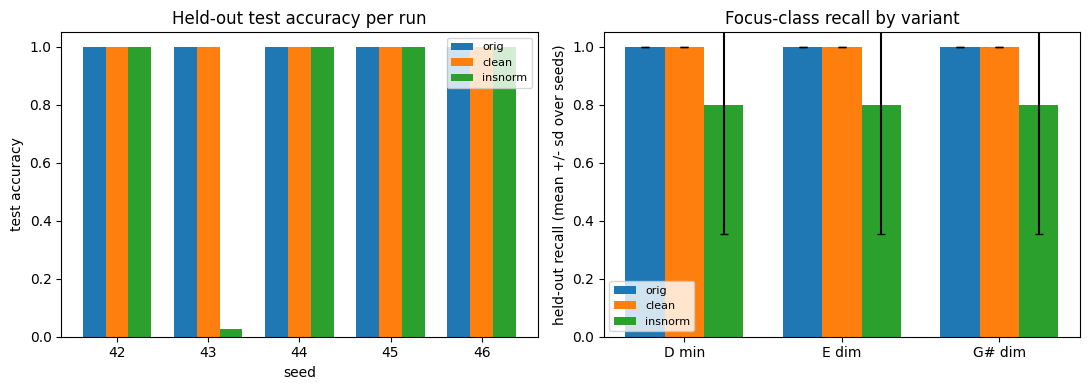

In [8]:
progress = load_progress()

if len(progress):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Left: test accuracy per seed, grouped by variant
    ax = axes[0]
    width = 0.25
    for i, variant in enumerate(VARIANTS):
        sub = progress[progress.variant == variant].sort_values("seed")
        xs = np.arange(len(sub)) + i * width
        ax.bar(xs, sub["test_accuracy"], width=width, label=variant)
    ax.set_xticks(np.arange(len(SEEDS)) + width)
    ax.set_xticklabels([str(s) for s in SEEDS])
    ax.set_xlabel("seed")
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title("Held-out test accuracy per run")
    ax.legend(fontsize=8)

    # Right: mean +/- sd across seeds, per variant, for the 3 focus classes' recall
    ax = axes[1]
    focus_cols = ["recall_D_minor_4", "recall_E_diminished_4", "recall_G#_diminished_4"]
    means = progress.groupby("variant")[focus_cols].mean()
    sds = progress.groupby("variant")[focus_cols].std()
    x = np.arange(len(focus_cols))
    for i, variant in enumerate(VARIANTS):
        if variant not in means.index:
            continue
        ax.bar(
            x + i * width, means.loc[variant], width=width,
            yerr=sds.loc[variant].fillna(0), capsize=3, label=variant,
        )
    ax.set_xticks(x + width)
    ax.set_xticklabels(["D min", "E dim", "G# dim"])
    ax.set_ylabel("held-out recall (mean +/- sd over seeds)")
    ax.set_ylim(0, 1.05)
    ax.set_title("Focus-class recall by variant")
    ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "final_metrics_summary.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("no completed runs yet")